# Workflow : Téléchargement et gestion des datasets

Ce notebook démontre l'utilisation des scripts `scripts/datasets/` pour télécharger,
consolider et visualiser des données de marché utilisées dans les stratégies QuantConnect.

**Prérequis** : `pip install pandas yfinance matplotlib`

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Répertoire de sortie par défaut pour les datasets
DATASETS_DIR = Path("../datasets")
DATASETS_DIR.mkdir(exist_ok=True)

print(f"Datasets dir: {DATASETS_DIR.resolve()}")

Datasets dir: /Lean/Launcher/bin/Debug/datasets


## 1. Téléchargement via yfinance

Utilise le script `download_yfinance.py` avec cache Parquet local.

In [2]:
# Télécharger SPY et TLT (actions/ETF)
!python ../../../scripts/datasets/download_yfinance.py --symbols SPY,TLT --start 2020-01-01 --end 2024-12-31 --output-dir {DATASETS_DIR}/yfinance

python: can't open file '/Lean/Launcher/bin/Debug/Notebooks/../../../scripts/datasets/download_yfinance.py': [Errno 2] No such file or directory


In [3]:
# Charger et afficher les données SPY
spy = pd.read_csv(DATASETS_DIR / "yfinance" / "SPY_2020-01-01_2024-12-31.csv", parse_dates=["Date"], index_col="Date")
print(f"SPY: {len(spy)} jours, {spy.index.min().date()} -> {spy.index.max().date()}")
spy.head()

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/yfinance/SPY_2020-01-01_2024-12-31.csv'

NameError: name 'spy' is not defined

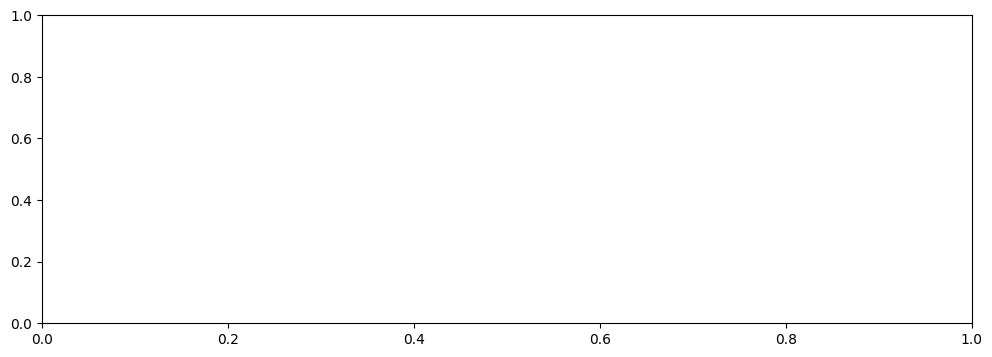

In [4]:
# Visualiser SPY Close
fig, ax = plt.subplots(figsize=(12, 4))
spy["Close"].plot(ax=ax, title="SPY Close Price (2020-2024)")
ax.set_ylabel("Price ($)")
plt.tight_layout()
plt.show()

## 2. Données crypto (archive consolidée)

Utilise `manage_crypto_archive.py` qui combine yfinance et CoinGecko.

In [5]:
# Construire l'archive BTC
!python ../../../scripts/datasets/manage_crypto_archive.py --symbol BTC --start 2019-01-01 --end 2024-12-31 --output-dir {DATASETS_DIR}/crypto_archive

python: can't open file '/Lean/Launcher/bin/Debug/Notebooks/../../../scripts/datasets/manage_crypto_archive.py': [Errno 2] No such file or directory


In [6]:
# Charger l'archive BTC
btc = pd.read_csv(DATASETS_DIR / "crypto_archive" / "BTC_USDT_archive.csv", parse_dates=["date"])
print(f"BTC: {len(btc)} jours, {btc['date'].min().date()} -> {btc['date'].max().date()}")
btc.head()

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/crypto_archive/BTC_USDT_archive.csv'

NameError: name 'btc' is not defined

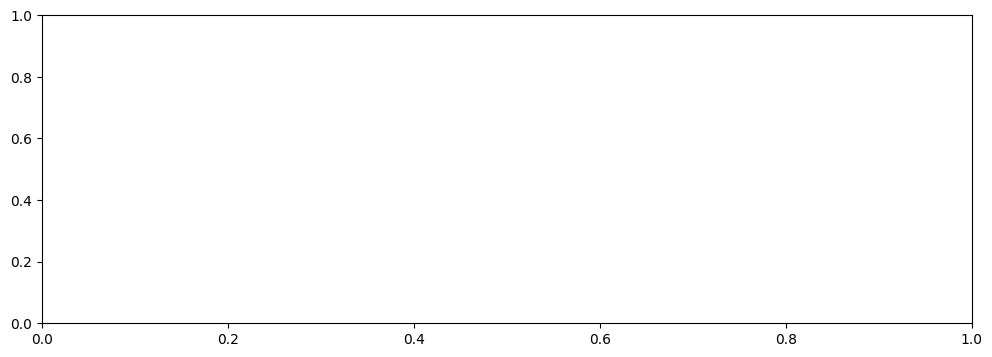

In [7]:
# Visualiser BTC Close
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(btc["date"], btc["close"])
ax.set_title("BTC/USDT Close Price (2019-2024)")
ax.set_ylabel("Price ($)")
plt.tight_layout()
plt.show()

## 3. Données Binance (klines haute résolution)

Pour des données intraday, utiliser `download_binance_archive.py`.

In [8]:
# Télécharger les klines journaliers BTC d'un mois
!python ../../../scripts/datasets/download_binance_archive.py --symbol BTCUSDT --start 2024-01-01 --end 2024-03-31 --interval 1d --output-dir {DATASETS_DIR}/binance

python: can't open file '/Lean/Launcher/bin/Debug/Notebooks/../../../scripts/datasets/download_binance_archive.py': [Errno 2] No such file or directory


In [9]:
# Lister et charger les fichiers Binance téléchargés
binance_files = sorted((DATASETS_DIR / "binance").glob("BTCUSDT_1d_*.csv"))
print(f"{len(binance_files)} fichiers Binance")

if binance_files:
    dfs = [pd.read_csv(f) for f in binance_files]
    btc_klines = pd.concat(dfs, ignore_index=True)
    btc_klines["date"] = pd.to_datetime(btc_klines["open_time"], unit="ms")
    print(f"Total: {len(btc_klines)} rangées")
    btc_klines.head()

0 fichiers Binance


## 4. Mise à jour de l'archive crypto

Pour mettre à jour une archive existante avec les données les plus récentes :

In [10]:
# Mettre à jour l'archive BTC (ajoute les nouvelles données)
!python ../../../scripts/datasets/manage_crypto_archive.py --symbol BTC --update --output-dir {DATASETS_DIR}/crypto_archive

python: can't open file '/Lean/Launcher/bin/Debug/Notebooks/../../../scripts/datasets/manage_crypto_archive.py': [Errno 2] No such file or directory


In [11]:
# Lister toutes les archives disponibles
!python ../../../scripts/datasets/manage_crypto_archive.py --list --output-dir {DATASETS_DIR}/crypto_archive

python: can't open file '/Lean/Launcher/bin/Debug/Notebooks/../../../scripts/datasets/manage_crypto_archive.py': [Errno 2] No such file or directory


## 5. Résumé des outils disponibles

| Script | Source | Cas d'usage |
|--------|--------|-------------|
| `download_yfinance.py` | Yahoo Finance | Actions, ETF, crypto (daily+) |
| `download_binance_archive.py` | Binance data.vision | Crypto intraday (1m-1d) |
| `download_kaggle.py` | Kaggle | Datasets académiques |
| `download_qc_data.py` | QuantConnect lean-cli | Données QC (equity, forex, futures) |
| `manage_crypto_archive.py` | yfinance + CoinGecko | Archive crypto consolidée |

Documentation complète : `scripts/datasets/README.md`